In [1]:
ROOT = "zigzag_results/cifar-10"

MODELS = {
    'vit_l_16': 'ViTl16',
    'vit_b_32': 'ViTb32',
    'resnet34': 'ResNet34'
}

N_COMPONENTS = [3, 4, 5]
PLOT_COMPONENT = 4

In [2]:
import os
import typing

def plan(model: str, n_components: int) -> typing.List[typing.Tuple[str, str, int]]:
    folder = f"{ROOT}/{model}"
    hs_folder = (
        f"{folder}/hidden_states"
        if os.path.exists(f"{folder}/hidden_states")
        else f"{folder}/features"
    )
    
    layers = os.listdir(hs_folder)
    if model == "vit_l_16" or model == "vit_b_32":
        layers = layers[1:]

    plan = []
    for hidden_state in layers:
        hs_no_ext = hidden_state[:hidden_state.index('.')]
        out_file = f"{folder}/spaces/{hs_no_ext}/{n_components}.txt"
        plan.append((f"{hs_folder}/{hs_no_ext}", out_file, n_components))
    return plan

In [3]:
import zigzag.space

params = []
for model in MODELS.keys():
    for n_components in N_COMPONENTS:
        params.extend(plan(model, n_components))
zigzag.space.process_bulk(params, n_jobs=4)
None

 93%|█████████▎| 148/159 [2:08:43<03:01, 16.51s/it]   d:\Programs\Programming\Python\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 159/159 [2:15:04<00:00, 50.97s/it]


In [4]:
import pandas

report = []
for model, title in MODELS.items():
    for n_components in N_COMPONENTS:
        item = zigzag.space.make_report(plan(model, n_components))
        report.append({'model': title, 'n_components': n_components, **item})

report = pandas.DataFrame(report)
report.to_csv(f"{ROOT}/spaces_report.csv")
report

100%|██████████| 17/17 [00:00<00:00, 17025.59it/s]


,model,n_components,layer_1,layer_2,layer_3,layer_4,layer_5,layer_6,layer_7,layer_8,...,layer_15,layer_16,layer_17,layer_18,layer_19,layer_20,layer_21,layer_22,layer_23,layer_24
0,ViTl16,3,"45.8%\n(3, 1, 1)\n(3, 1, 1)","15.0%\n(2, 1, 1)\n(2, 1, 1)","14.8%\n(2, 3, 1)\n(2, 3, 1)","15.0%\n(2, 3, 1)\n(2, 3, 1)","14.5%\n(2, 1, 1)\n(2, 1, 1)","13.9%\n(2, 2, 1)\n(2, 2, 1)","13.8%\n(2, 1, 4)\n(2, 1, 4)","13.7%\n(2, 9, 5)\n(2, 9, 5)",...,"13.4%\n(2, 1, 5)\n(2, 1, 5)","13.4%\n(2, 1, 5)\n(2, 1, 5)","13.4%\n(2, 1, 5)\n(2, 1, 5)","31.5%\n(2, 1, 2)\n(2, 1, 2)","27.4%\n(2, 1, 1)\n(2, 1, 1)","23.6%\n(2, 3, 1)\n(2, 3, 1)","20.7%\n(2, 3, 2)\n(2, 3, 2)","17.5%\n(2, 4, 18)\n(2, 4, 18)","16.0%\n(2, 1, 2)\n(2, 1, 2)","15.4%\n(2, 3, 2)\n(2, 3, 2)"
1,ViTl16,4,"55.0%\n(4, 2, 20, 1)\n(4, 2, 20, 1)","18.0%\n(2, 15, 3, 1)\n(2, 15, 3, 1)","17.7%\n(2, 1, 1, 1)\n(2, 1, 1, 1)","18.2%\n(2, 5, 1, 2)\n(2, 5, 1, 2)","17.7%\n(13, 4, 2, 8)\n(13, 4, 2, 8)","17.2%\n(3, 3, 1, 1)\n(3, 3, 1, 1)","17.0%\n(2, 1, 1, 3)\n(2, 1, 1, 3)","16.8%\n(6, 1, 3, 1)\n(6, 1, 3, 1)",...,"16.6%\n(6, 1, 11, 1)\n(6, 1, 11, 1)","16.6%\n(6, 1, 1, 9)\n(6, 1, 1, 9)","16.6%\n(6, 1, 1, 9)\n(6, 1, 1, 9)","37.5%\n(4, 1, 1, 4)\n(4, 1, 1, 4)","32.5%\n(11, 8, 4, 1)\n(11, 8, 4, 1)","28.3%\n(4, 4, 1, 1)\n(4, 4, 1, 1)","24.9%\n(2, 4, 6, 1)\n(2, 4, 6, 1)","21.4%\n(2, 2, 2, 26)\n(2, 2, 2, 26)","19.6%\n(3, 1, 3, 1)\n(3, 1, 3, 1)","18.5%\n(2, 3, 1, 1)\n(2, 3, 1, 1)"
2,ViTl16,5,"62.9%\n(2, 6, 3, 2, 2)\n(2, 6, 3, 2, 2)","21.0%\n(3, 1, 1, 3, 1)\n(3, 1, 1, 3, 1)","20.5%\n(3, 8, 1, 1, 2)\n(3, 8, 1, 1, 2)","20.9%\n(3, 4, 1, 1, 2)\n(3, 4, 1, 1, 2)","20.4%\n(2, 2, 1, 1, 1)\n(2, 2, 1, 1, 1)","19.8%\n(3, 1, 4, 1, 1)\n(3, 1, 4, 1, 1)","19.5%\n(2, 2, 3, 4, 3)\n(2, 2, 3, 4, 3)","19.4%\n(4, 10, 1, 2, 4)\n(4, 10, 1, 2, 4)",...,"19.1%\n(3, 1, 1, 2, 1)\n(3, 1, 1, 2, 1)","19.1%\n(2, 2, 1, 3, 1)\n(2, 2, 1, 3, 1)","19.1%\n(2, 2, 1, 3, 1)\n(2, 2, 1, 3, 1)","43.1%\n(2, 6, 1, 1, 2)\n(2, 6, 1, 1, 2)","37.4%\n(2, 9, 1, 16, 1)\n(2, 9, 1, 16, 1)","32.5%\n(2, 1, 1, 1, 1)\n(2, 1, 1, 1, 1)","28.4%\n(4, 2, 1, 2, 7)\n(4, 2, 1, 2, 7)","24.9%\n(3, 1, 1, 1, 3)\n(3, 1, 1, 1, 3)","22.8%\n(3, 1, 1, 13, 1)\n(3, 1, 1, 13, 1)","21.6%\n(3, 4, 1, 2, 1)\n(3, 4, 1, 2, 1)"
3,ViTb32,3,"61.5%\n(4, 6, 1)\n(4, 6, 1)","17.6%\n(2, 10, 1)\n(2, 10, 1)","23.1%\n(3, 9, 2)\n(3, 9, 2)","36.0%\n(2, 3, 1)\n(2, 3, 1)","46.0%\n(2, 1, 1)\n(2, 1, 1)","34.2%\n(2, 8, 1)\n(2, 8, 1)","31.3%\n(2, 3, 0)\n(2, 3, 0)","27.2%\n(2, 1, 0)\n(2, 1, 0)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ViTb32,4,"66.5%\n(2, 2, 1, 0)\n(2, 2, 1, 0)","21.4%\n(3, 5, 1, 0)\n(3, 5, 1, 0)","26.5%\n(2, 8, 1, 0)\n(2, 8, 1, 0)","39.7%\n(2, 1, 1, 0)\n(2, 1, 1, 0)","51.1%\n(6, 1, 2, 0)\n(6, 1, 2, 0)","39.4%\n(3, 2, 6, 0)\n(3, 2, 6, 0)","35.8%\n(6, 1, 9, 0)\n(6, 1, 9, 0)","31.6%\n(2, 2, 1, 0)\n(2, 2, 1, 0)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ViTb32,5,"71.1%\n(3, 1, 2, 0, 0)\n(3, 1, 2, 0, 0)","24.6%\n(2, 1, 2, 2, 0)\n(2, 1, 2, 2, 0)","29.6%\n(3, 1, 1, 1, 0)\n(3, 1, 1, 1, 0)","42.2%\n(3, 1, 1, 1, 0)\n(3, 1, 1, 1, 0)","55.4%\n(2, 4, 1, 0, 0)\n(2, 4, 1, 0, 0)","43.9%\n(17, 5, 4, 1, 0)\n(17, 5, 4, 1, 0)","40.1%\n(2, 1, 2, 0, 0)\n(2, 1, 2, 0, 0)","35.4%\n(11, 2, 1, 0, 0)\n(11, 2, 1, 0, 0)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ResNet34,3,"24.4%\n(3, 7, 51)\n(3, 7, 51)","20.9%\n(3, 2, 2)\n(3, 2, 2)","4.7%\n(6, 1, 1)\n(6, 1, 1)","5.7%\n(4, 6, 3)\n(4, 6, 3)","5.5%\n(2, 1, 1)\n(2, 1, 1)","6.1%\n(3, 1, 1)\n(3, 1, 1)","7.6%\n(2, 1, 2)\n(2, 1, 2)","8.6%\n(2, 1, 1)\n(2, 1, 1)",...,"11.4%\n(2, 2, 2)\n(2, 2, 2)","6.1%\n(2, 1, 1)\n(2, 1, 1)","4.8%\n(2, 2, 7)\n(2, 2, 7)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ResNet34,4,"27.4%\n(7775, 7, 1, 11)\n(7775, 7, 1, 11)","24.4%\n(2, 2, 6, 21)\n(2, 2, 6, 21)","5.6%\n(2, 3, 10, 1)\n(2, 3, 10, 1)","6.7%\n(11, 1, 4, 2)\n(11, 1, 4, 2)","6.6%\n(2, 1, 2, 1)\n(2, 1, 2, 1)","7.3%\n(2, 8, 2, 3)\n(2, 8, 2, 3)","8.9%\n(2, 7, 2, 1)\n(2, 7, 2, 1)","10.2%\n(2, 5, 4, 1)\n(2, 5, 4, 1)",...,"13.3%\n(3, 1, 4, 3)\n(3, 1, 4, 3)","7.2%\n(4, 1, 2, 2)\n(4, 1, 2, 2)","5.7%\n(3, 7, 2, 2)\n(3,

100%|██████████| 17/17 [00:00<00:00, 8492.52it/s]


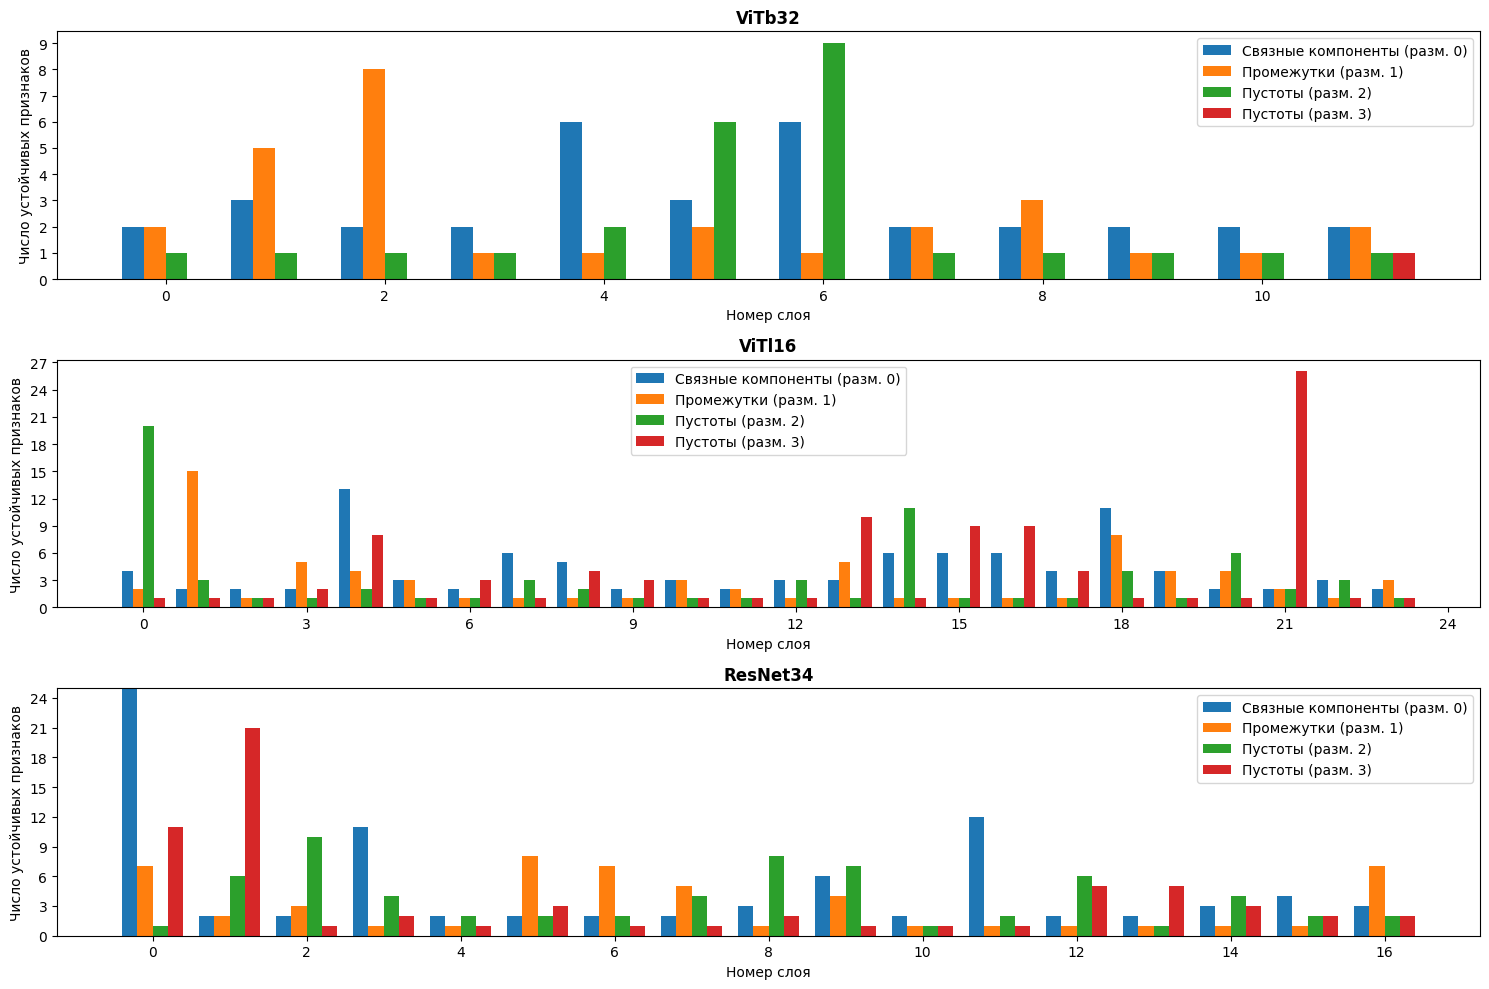

In [5]:
import matplotlib.pyplot as plt

AX_IDX = { 'vit_l_16': 1, 'vit_b_32': 0, 'resnet34': 2 }
fig, axes = plt.subplots(3, 1, figsize = (15, 10))
for model, title in MODELS.items():
    ax = axes.flat[AX_IDX[model]]
    ax.set_title(title, fontweight='bold')
    zigzag.space.plot(plan(model, PLOT_COMPONENT), ax)
    ax.legend(loc='best')
    if model != "vit_b_32" and model != "vit_l_16":
        ax.set_ylim((0, 25))

fig.tight_layout()
fig.savefig(f"{ROOT}/spaces_plots.png")
fig.savefig(f"{ROOT}/spaces_plots.svg")